In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import shap

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [44]:
df=pd.read_csv("data_avec_clusters (1).csv")

In [45]:
df.drop(['Unnamed: 0.1',"Unnamed: 0"],axis=1,inplace=True)

In [46]:
y = df["cluster_gmm"]
features = ["cluster_proba","cluster_gmm","Yield strength (MPa)","Charpy impact toughness (J)","Reduction of Area (%)","Elongation (%)" ,"Ultimate tensile strength (MPa)","Charpy temperature (°C)"]

X = df.drop(columns=features)

print(X.shape, y.shape)

(1639, 40) (1639,)


In [47]:
y = df["cluster_gmm"].astype(int)

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train set: {X_train.shape}")
print(f"Test set: {X_test.shape}")

Train set: (1311, 40)
Test set: (328, 40)


In [49]:
from xgboost import XGBClassifier


In [71]:
from sklearn.ensemble import HistGradientBoostingClassifier

model = HistGradientBoostingClassifier(
    max_iter=100,
    max_depth=6,
    learning_rate=0.1,
    random_state=42
)

In [72]:
model.fit(X_train, y_train)


HistGradientBoostingClassifier(max_depth=6, random_state=42)

In [73]:
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")

Accuracy: 0.9512


In [69]:
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.90      0.96      0.93       137
           1       0.93      0.93      0.93        15
           2       0.98      0.93      0.95       176

    accuracy                           0.94       328
   macro avg       0.94      0.94      0.94       328
weighted avg       0.94      0.94      0.94       328



Feature Importance (XGBoost natif)


In [54]:

importance_gain = model.get_booster().get_score(importance_type='gain')

feat_imp_df = pd.DataFrame({
    'feature': list(importance_gain.keys()),
    'importance': list(importance_gain.values())
}).sort_values('importance', ascending=False)

feat_imp_df.head(10)

,feature,importance
7,Molybdenum concentration (weight%),17.302349
27,weld_type_FCA,8.558634
4,Phosphorus concentration (weight%),5.675601
6,Chromium concentration (weight%),4.269038
22,Heat input (kJmm-1),2.982308
20,Current (A),2.297926
21,Voltage (V),2.200132
16,Niobium concentration (ppm by weight),1.987847
5,Nickel concentration (weight%),1.832555
9,Copper concentration (weight%),1.630980


<Figure size 1000x800 with 0 Axes>

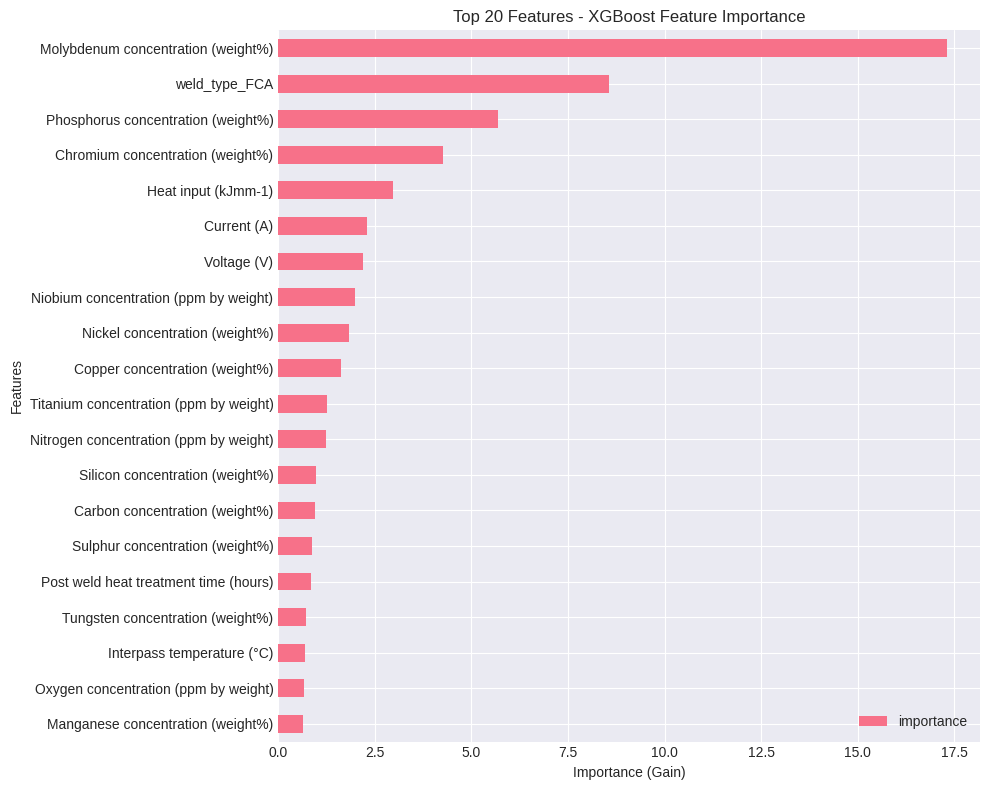

In [55]:
plt.figure(figsize=(10, 8))
feat_imp_df.head(20).plot(x='feature', y='importance', kind='barh', figsize=(10, 8))
plt.xlabel('Importance (Gain)')
plt.ylabel('Features')
plt.title('Top 20 Features - XGBoost Feature Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

SHAP - Initialisation

In [74]:
explainer = shap.TreeExplainer(model)


In [76]:
# Calculer les valeurs SHAP sur l'ensemble de test
shap_values = explainer(X_test)
print(f" Valeurs SHAP calculées: {shap_values.values.shape}")

 Valeurs SHAP calculées: (328, 40, 3)


#Summary plot (vue d'ensemble)

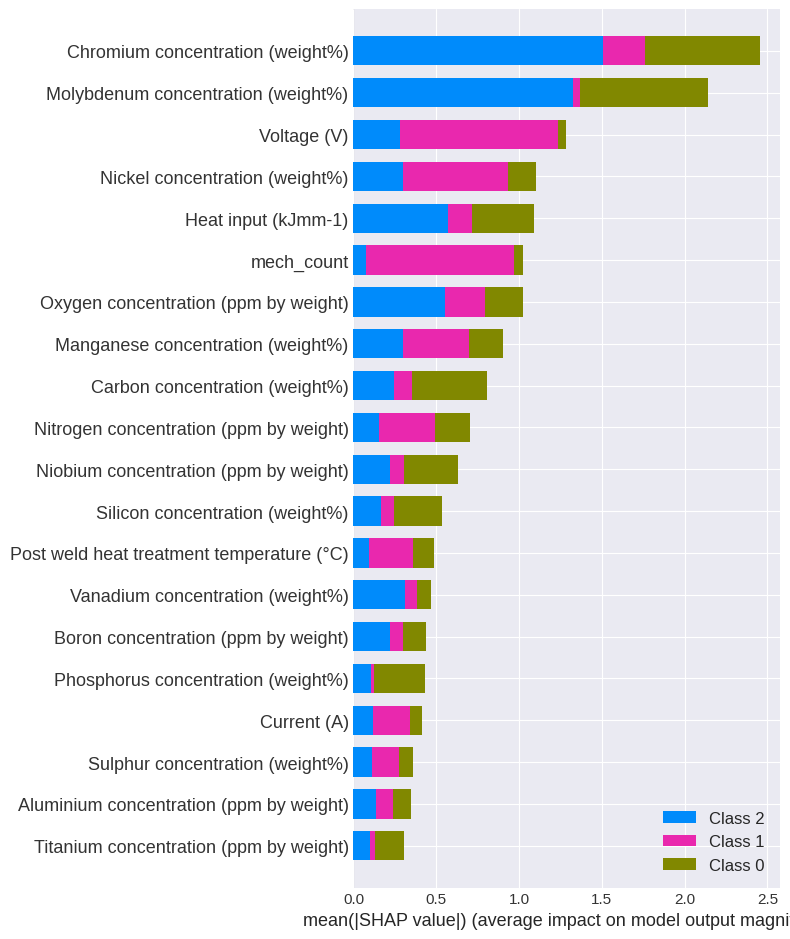

In [78]:

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.show()

Chaque barre correspond à une variable d’entrée (feature) de ton modèle, et la longueur de la barre indique l’importance moyenne absolue des valeurs SHAP → autrement dit :

à quel point cette variable influence les prédictions du modèle, toutes classes confondues.

#SHAP - Analyse par classe

Nombre de classes: 3


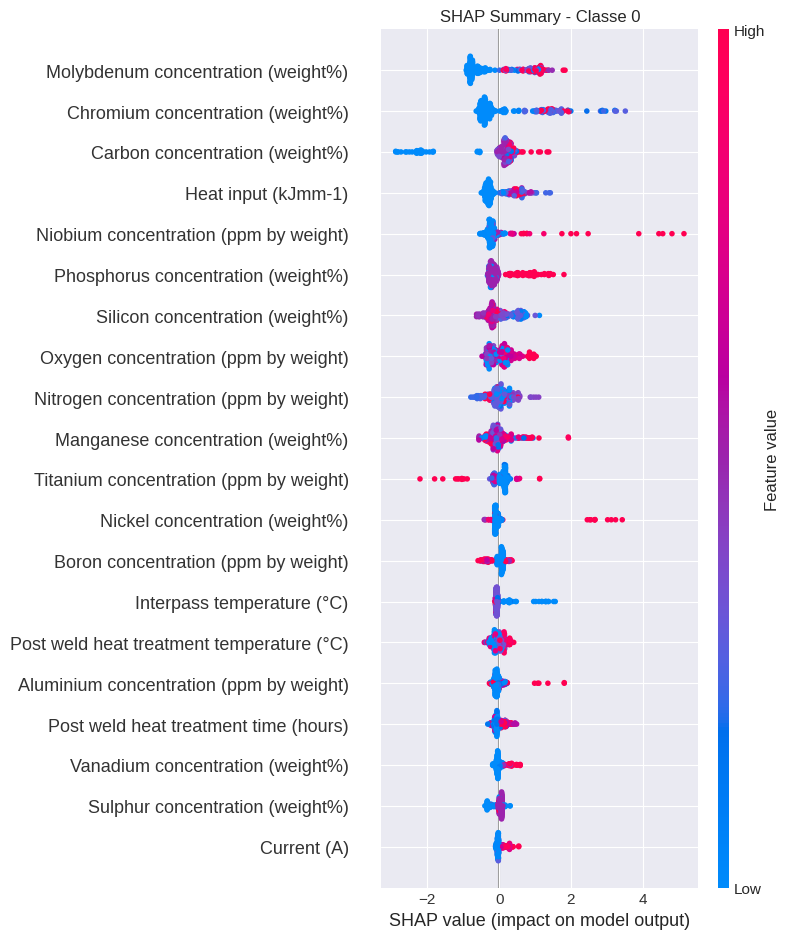

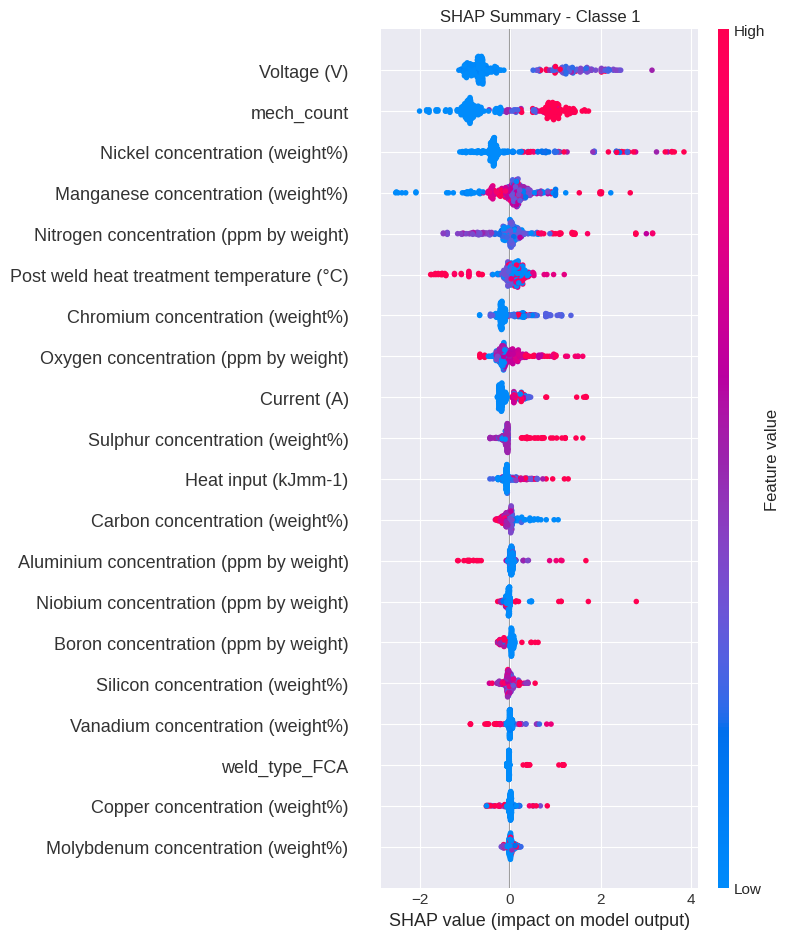

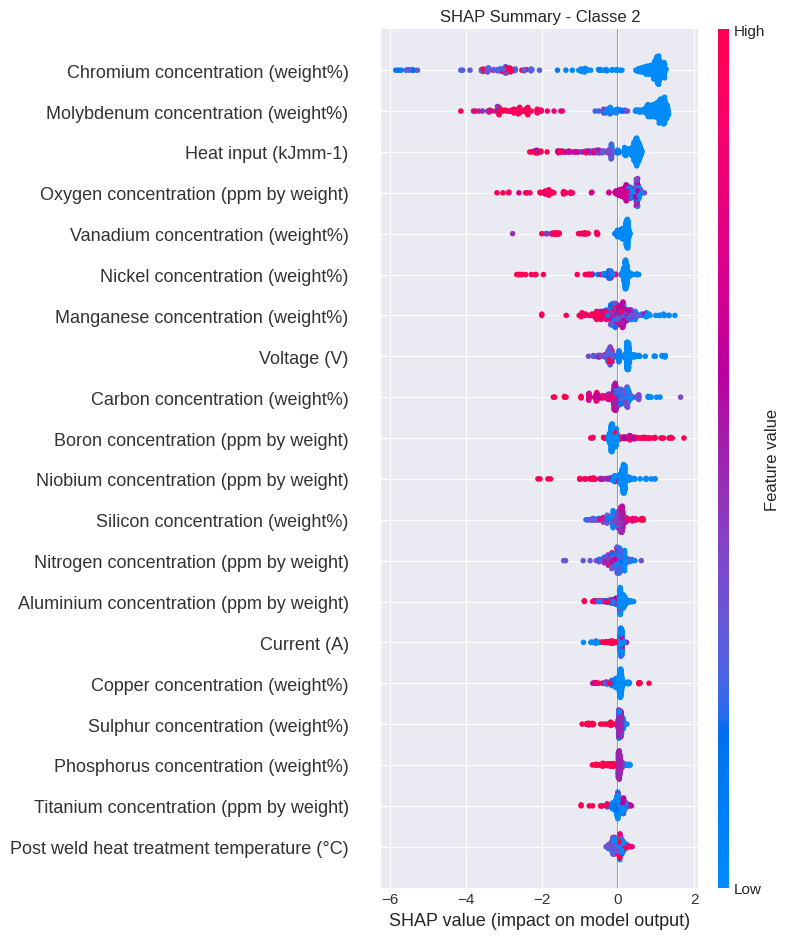

In [81]:

n_classes = len(np.unique(y_train))
print(f"Nombre de classes: {n_classes}")

n_classes = 3
for i in range(min(3, n_classes)):
    plt.figure(figsize=(12, 6))
    shap.summary_plot(shap_values[:,:,i], X_test, show=False)
    plt.title(f'SHAP Summary - Classe {i}')
    plt.tight_layout()
    plt.show()

.Chaque point = une observation (une soudure dans ton jeu de données).

.Position horizontale (axe x) : effet SHAP →

-à droite : la variable augmente la probabilité d’être en classe i,

-à gauche : elle la diminue.

.Couleur : valeur de la feature

-rouge = valeur élevée,

-bleu = valeur faible.

#SHAP - Dependence Plots

In [83]:
top_features = feat_imp_df.head(5)['feature'].tolist()
print("Top 5 features:", top_features)

Top 5 features: ['Molybdenum concentration (weight%)', 'weld_type_FCA', 'Phosphorus concentration (weight%)', 'Chromium concentration (weight%)', 'Heat input (kJmm-1)']


<Figure size 1000x600 with 0 Axes>

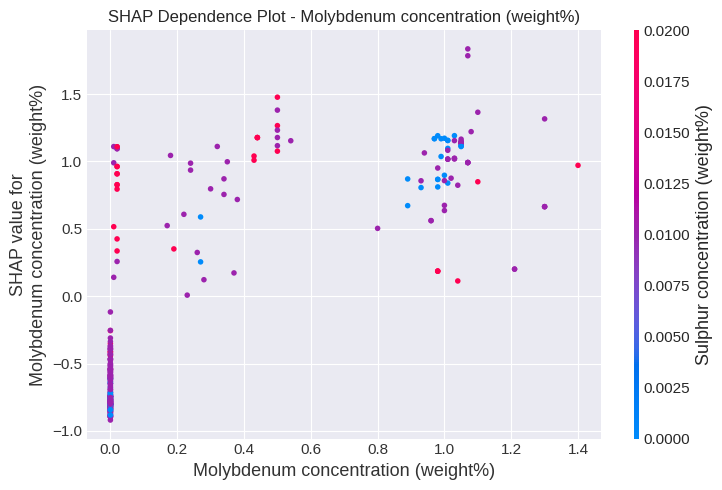

<Figure size 1000x600 with 0 Axes>

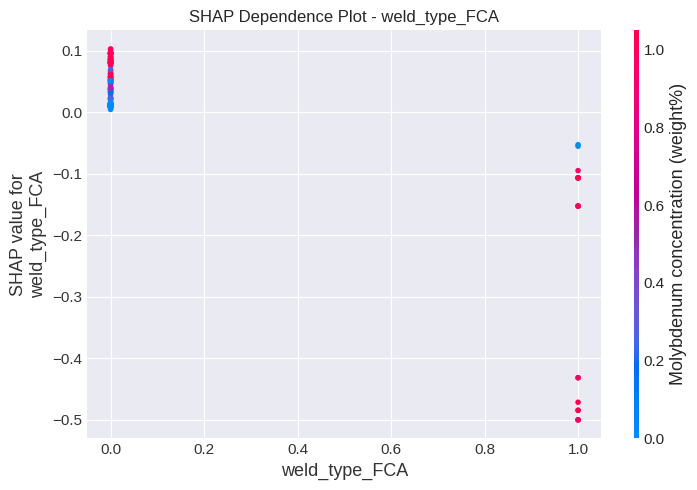

<Figure size 1000x600 with 0 Axes>

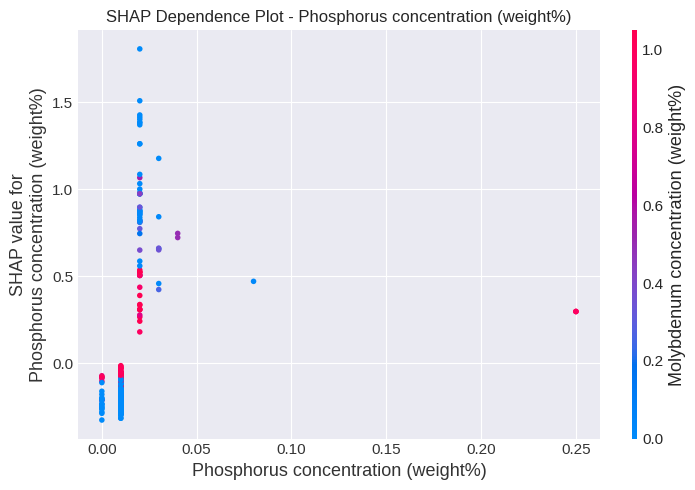

<Figure size 1000x600 with 0 Axes>

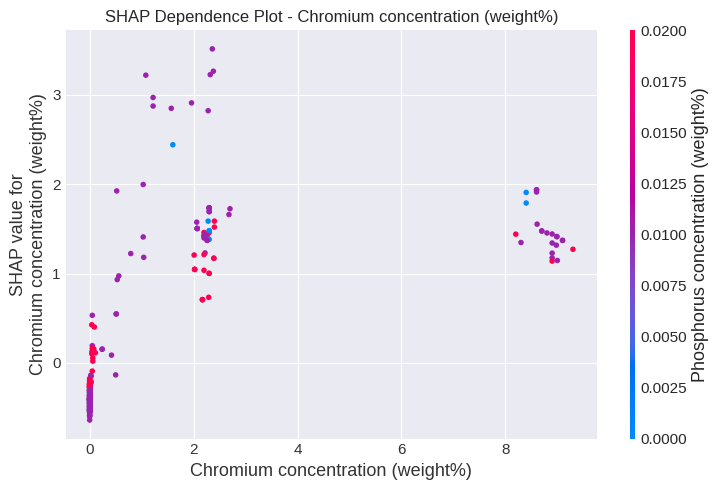

<Figure size 1000x600 with 0 Axes>

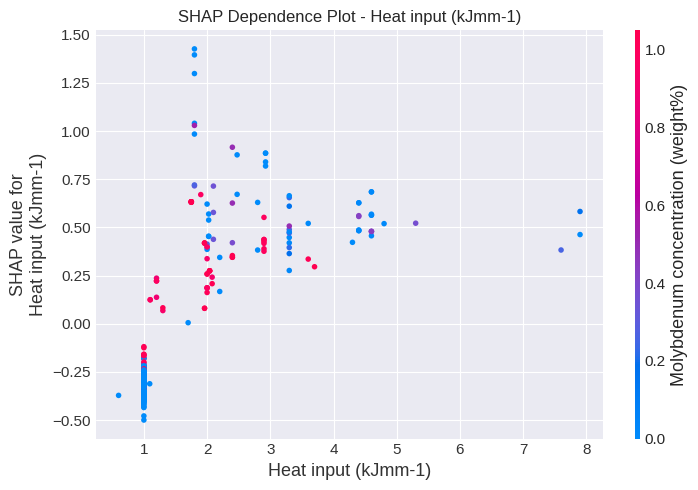

In [84]:
for feature in top_features:
    plt.figure(figsize=(10, 6))
    shap.dependence_plot(
        feature,
        shap_values.values[:,:,0] if len(shap_values.values.shape) == 3 else shap_values.values,
        X_test,
        show=False
    )
    plt.title(f'SHAP Dependence Plot - {feature}')
    plt.tight_layout()
    plt.show()

SHAP - Force Plot

In [88]:
shap.initjs()
shap.force_plot(
    explainer.expected_value[0] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value,
    shap_values[0].values[:, 0] if len(shap_values[0].values.shape) == 2 else shap_values[0].values,
    X_test.iloc[0, :]
)

##  Interprétation du graphique SHAP (force plot)

Ce graphique montre comment chaque variable contribue à la prédiction du modèle pour un échantillon donné (ici, la classe 0).

- **La ligne horizontale** représente la progression de la prédiction à partir de la valeur de base (moyenne du modèle).
- **Les segments rouges** indiquent les variables qui **augmentent** la probabilité d’appartenir à la classe 0.
- **Les segments bleus** indiquent celles qui **la réduisent**.

Dans cet exemple :
- Les concentrations élevées en **Phosphore (P)**, **Manganèse (Mn)** et **Nickel (Ni)** poussent la prédiction vers la droite → elles **favorisent la classe 0**.
- En revanche, une faible **concentration en Molybdène (Mo)** et un **apport thermique (Heat Input)** spécifique tirent la prédiction vers la gauche → elles **diminuent la probabilité d’être en classe 0**.

La somme de tous ces effets aboutit à la valeur finale de prédiction (*f(x) = 3.50*).  
 Autrement dit, pour cette soudure, la composition chimique (P, Mn, Ni élevés) a fortement orienté le modèle vers la classe 0.


SHAP - Decision Plot

<Figure size 1000x600 with 0 Axes>

<Figure size 1000x600 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

<Figure size 1400x1000 with 0 Axes>

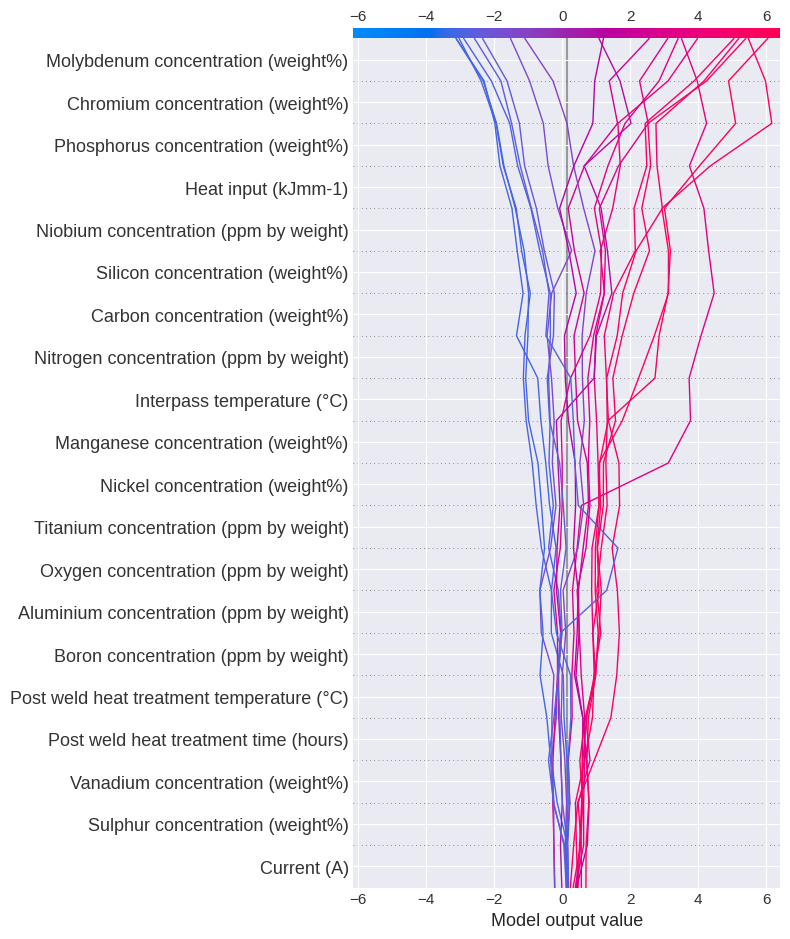

In [94]:

plt.figure(figsize=(12, 8))
shap.decision_plot(
    explainer.expected_value[0] if isinstance(explainer.expected_value, np.ndarray) else explainer.expected_value,
    shap_values[:20].values[:, :, 0] if len(shap_values.values.shape) == 3 else shap_values[:20].values,
    X_test.iloc[:20, :],
    show=False
)
plt.tight_layout()
plt.show()

##  Interprétation du graphique SHAP – Decision Plot

Ce graphique montre **comment les variables contribuent collectivement à la décision du modèle** pour plusieurs échantillons (ici les 20 premiers de `X_test`).

- Chaque **ligne** représente une soudure (ou un échantillon).  
- L’axe horizontal indique **la valeur de sortie du modèle** (output value), c’est-à-dire la probabilité relative d’appartenir à la classe analysée.  
- Les **couleurs** vont du bleu (valeurs faibles) au rouge (valeurs élevées) pour chaque variable.

###  Lecture physique
- Les **éléments d’alliage majeurs** comme **Molybdène (Mo)** et **Chromium (Cr)** influencent fortement la décision :  
  → des teneurs élevées (rouge) déplacent les prédictions vers la droite (probabilité plus forte),  
  → des teneurs faibles (bleu) tirent les lignes vers la gauche.  
- Les variables comme **Phosphore**, **Heat Input**, ou **Niobium** participent aussi à cette séparation, en modifiant progressivement la sortie du modèle.
- Les lignes qui montent rapidement vers la droite correspondent à des soudures **très caractéristiques de la classe considérée** ; celles qui restent proches de 0 sont **neutres ou ambiguës**.

En résumé, ce diagramme permet de **suivre pas à pas l’effet cumulé de chaque variable** sur la décision finale du modèle, et de repérer quelles combinaisons de composition chimique et de paramètres de soudage mènent à une appartenance forte ou faible à la classe étudiée.


Analyse des interactions SHAP

In [95]:

shap_interaction_values = explainer.shap_interaction_values(X_test.iloc[:100])
print(f"✓ Interactions SHAP calculées: {shap_interaction_values.shape}")

✓ Interactions SHAP calculées: (100, 40, 40, 3)


"""
 Interprétation du calcul des interactions SHAP

Ce bloc calcule les valeurs d’interaction SHAP pour les 100 premiers échantillons du jeu de test.
Chaque matrice d’interaction (40 x 40) montre comment deux variables influencent ensemble la prédiction du modèle.

- Les valeurs sur la diagonale représentent les effets individuels classiques (impact direct de chaque variable).
- Les valeurs hors diagonale représentent les effets d’interaction entre deux variables (effet combiné).
- La dernière dimension (3) correspond aux trois classes du problème de classification.

En résumé :
→ Ce calcul permet d’identifier quelles combinaisons de variables (par exemple Molybdène et Chrome)
   renforcent ou atténuent mutuellement la probabilité d’appartenir à une classe donnée.



Analyse comparative

In [99]:

shap_importance = np.abs(shap_values.values).mean(axis=0)

if len(shap_importance.shape) == 2:
    shap_importance = shap_importance.mean(axis=1)

shap_imp_df = pd.DataFrame({
    'feature': X_test.columns,
    'shap_importance': shap_importance
}).sort_values('shap_importance', ascending=False)

shap_imp_df.head(10)

,feature,shap_importance
6,Chromium concentration (weight%),0.817854
7,Molybdenum concentration (weight%),0.713387
22,Voltage (V),0.427923
5,Nickel concentration (weight%),0.367700
25,Heat input (kJmm-1),0.362692
29,mech_count,0.342155
12,Oxygen concentration (ppm by weight),0.341037
2,Manganese concentration (weight%),0.301714
0,Carbon concentration (weight%),0.269592
14,Nitrogen concentration (ppm by weight),0.234436


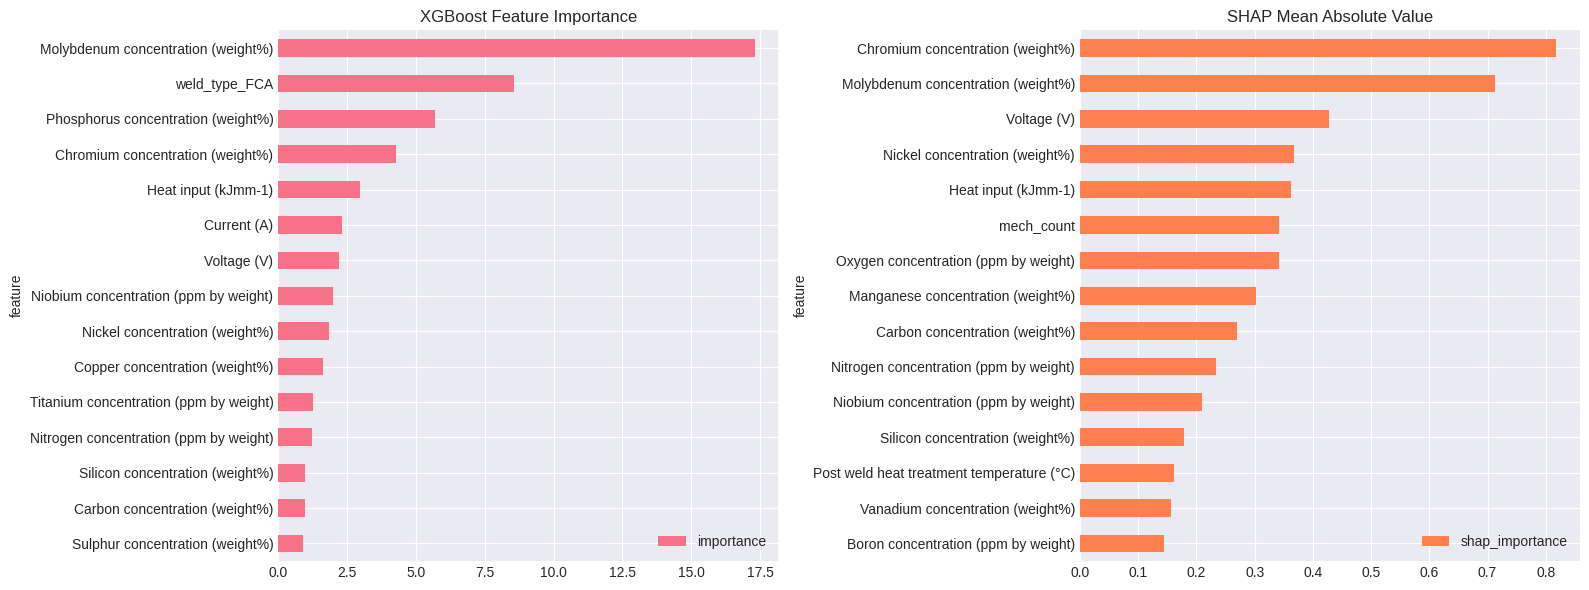

In [102]:
# Visualisation comparative
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# XGBoost importance
feat_imp_df.head(15).plot(x='feature', y='importance', kind='barh', ax=axes[0])
axes[0].set_title('XGBoost Feature Importance')
axes[0].invert_yaxis()

# SHAP importance
shap_imp_df.head(15).plot(x='feature', y='shap_importance', kind='barh', ax=axes[1], color='coral')
axes[1].set_title('SHAP Mean Absolute Value')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()